# 경복궁 시계열 분석 전 EDA

이 노트북은 **시계열 모델링 전에 데이터 상태와 외생변수 후보를 점검**하는 용도다.

EDA 목표:
- 경복궁 일별 방문객 시계열의 기본 패턴 확인
- 코로나 구간, 이벤트일, 계절/날씨 변수의 수준 차이 확인
- 결측, 0값, 변수 중복성, 시차 상관을 점검
- SARIMAX 전용 feature set 후보를 정리

주의:
- `paid`, `free`, `domestic`, `foreign_total` 등 방문객 구성항목은 **설명용으로만 보고 모델 후보에서는 제외**한다.
- `covid_v1`, `covid_v2`, `covid_v3`는 **중첩 더미**이므로 동시에 넣지 않는다.
- `closed`, `others_closed`, `d_holiday`는 `preprocessing/visitors_gbg.py`에서 직접 계산한 값을 사용한다.
- 모델링용 PM 변수는 `ydst_pm10_open_hours`를 대표값으로 보고, `pm10` alias도 같이 저장한다.


In [1]:
# ============================================================
# 0. 라이브러리 / 경로 설정
# ============================================================
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display

plt.style.use("default")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

fonts = {f.name for f in fm.fontManager.ttflist}

if os.name == "nt":
    font_name = "Malgun Gothic"
elif "AppleGothic" in fonts:
    font_name = "AppleGothic"
elif "NanumGothic" in fonts:
    font_name = "NanumGothic"
else:
    font_name = "DejaVu Sans"

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("사용 폰트:", font_name)

NOTEBOOK_DIR_CANDIDATES = [Path.cwd(), Path.cwd() / "modeling"]
NOTEBOOK_DIR = None
for candidate in NOTEBOOK_DIR_CANDIDATES:
    if (candidate / "eda_covid_clean.ipynb").exists():
        NOTEBOOK_DIR = candidate
        break

if NOTEBOOK_DIR is None:
    raise FileNotFoundError("modeling/eda_covid_clean.ipynb 위치를 찾을 수 없습니다.")

PROJECT_ROOT = NOTEBOOK_DIR.parent
PREPROCESSED_DIR = PROJECT_ROOT / "data" / "preprocessed"

VISITORS_PATH = PREPROCESSED_DIR / "visitors_gbg_daily.csv"
ASOS_PATH = PREPROCESSED_DIR / "asos_seoul_daily.csv"
YDST_PATH = PREPROCESSED_DIR / "ydst_seoul_daily.csv"
COVID_PATH = PREPROCESSED_DIR / "covid_dummy_daily.csv"
EVENT_PATH = PREPROCESSED_DIR / "daily_event_features_gbg.csv"
KTCI_PATH = PREPROCESSED_DIR / "ktci.csv"
MASTER_OUTPUT_PATH = PREPROCESSED_DIR / "eda_gbg_master.csv"


사용 폰트: AppleGothic


In [2]:
# ============================================================
# 1. 데이터 로드
# ============================================================
visitors = pd.read_csv(VISITORS_PATH, encoding="utf-8-sig")
asos = pd.read_csv(ASOS_PATH, encoding="utf-8-sig")
ydst = pd.read_csv(YDST_PATH, encoding="utf-8-sig")
covid = pd.read_csv(COVID_PATH, encoding="utf-8-sig")
events = pd.read_csv(EVENT_PATH, encoding="utf-8-sig")
ktci = pd.read_csv(KTCI_PATH, encoding="utf-8-sig")

for frame in [visitors, asos, ydst, covid, events, ktci]:
    date_col = "date" if "date" in frame.columns else "날짜"
    frame[date_col] = pd.to_datetime(frame[date_col])

print("visitors:", visitors.shape)
print("asos    :", asos.shape)
print("ydst    :", ydst.shape)
print("covid   :", covid.shape)
print("events  :", events.shape)
print("ktci    :", ktci.shape)

display(visitors.head(2))
display(asos.head(2))
display(ydst.head(2))

visitors: (6209, 29)
asos    : (6209, 25)
ydst    : (5978, 21)
covid   : (6209, 8)
events  : (644, 31)
ktci    : (6209, 26)


,date,year,month,day,dow,dow_name,is_weekend,is_regular_closed_tuesday,closed,others_closed,d_holiday,close_hour,last_entry_hour,scheduled_open_hours_nominal,scheduled_entry_hours_nominal,visitors,cdg_visitors,cgg_visitors,dsg_visitors,paid,free,domestic,english,japanese,chinese,other_foreign,foreign_total,source_year,source_file
0,2009-01-01,2009,1,1,3,목,0,0,0,0,1,17.000,16.000,8.000,7.000,9966,2553,1064,5840,7866,2100,4621,666,1352,3327,0,5345,2009,문화재청_궁능유적본부_4대궁_관람객_수_현황_2009년.csv
1,2009-01-02,2009,1,2,4,금,0,0,0,0,0,17.000,16.000,8.000,7.000,7871,2307,859,5508,6103,1768,4417,440,748,2128,138,3454,2009,문화재청_궁능유적본부_4대궁_관람객_수_현황_2009년.csv


,date,year,month,day,dow,dow_name,is_weekend,station,tavg,tmin,tmax,rain,rain_yn,snow_fresh_max,snow_depth_max,snow_fresh_3h_total,snow_yn,pleasant,pleasant_streak,wind_avg,humidity_avg,sunshine,cloud_avg,solar_total,source_file
0,2009-01-01,2009,1,1,3,목,0,108,-5.800,-9.500,-2.500,0.000,0,0.000,0.000,0.000,0,0,0,2.300,45.800,8.800,0.000,9.490,SURFACE_ASOS_108_DAY_2009_2009_2018.csv
1,2009-01-02,2009,1,2,4,금,0,108,-2.800,-6.900,1.200,0.000,0,0.000,0.000,0.000,0,0,0,1.600,51.500,8.800,0.000,8.870,SURFACE_ASOS_108_DAY_2009_2009_2018.csv


,date,year,month,day,dow,dow_name,is_weekend,is_regular_closed_tuesday,station,close_hour,last_entry_hour,scheduled_open_hours_nominal,scheduled_entry_hours_nominal,ydst_pm10_all_hours,ydst_pm10_count_all_hours,ydst_pm10_open_hours,ydst_pm10_count_open_hours,ydst_pm10_entry_hours,ydst_pm10_count_entry_hours,ydst_pm10_high,source_files
0,2009-01-01,2009,1,1,3,목,0,0,108,17.000,16.000,8.000,7.000,43.739,23,43.000,8,43.143,7,0,ENV_YDST_108_HR_2009_2009_2017.csv
1,2009-01-02,2009,1,2,4,금,0,0,108,17.000,16.000,8.000,7.000,45.750,24,52.250,8,53.571,7,0,ENV_YDST_108_HR_2009_2009_2017.csv


In [3]:
# ============================================================
# 2. EDA용 병합 데이터 생성
# ============================================================
ktci = ktci.rename(
    columns={
        "날짜": "date",
        "KTCI": "ktci",
        "KTCI-a": "ktci_a",
        "KTCI-a2": "ktci_a2",
        "KTCI-a_roll3": "ktci_a_roll3",
        "KTCI-a_roll7": "ktci_a_roll7",
        "등급": "ktci_grade",
        "등급_a": "ktci_a_grade",
        "등급_a2": "ktci_a2_grade",
        "계절": "season_month",
        "계절_a": "season_temp",
        "최고기온": "ktci_tmax",
        "평균기온": "ktci_tavg",
        "강수량": "ktci_rain",
        "풍속": "ktci_wind",
        "일조시간": "ktci_sunshine",
        "전운량": "ktci_cloud",
    }
)

visitors_keep = [
    "date", "year", "month", "day", "dow", "dow_name", "is_weekend",
    "is_regular_closed_tuesday", "closed", "others_closed", "d_holiday",
    "close_hour", "last_entry_hour", "scheduled_open_hours_nominal",
    "scheduled_entry_hours_nominal", "visitors", "cdg_visitors",
    "cgg_visitors", "dsg_visitors", "paid", "free", "domestic",
    "english", "japanese", "chinese", "other_foreign", "foreign_total",
]

asos_keep = [
    "date", "tavg", "tmin", "tmax", "rain", "rain_yn",
    "snow_fresh_max", "snow_depth_max", "snow_fresh_3h_total", "snow_yn",
    "pleasant", "pleasant_streak", "wind_avg", "humidity_avg",
    "sunshine", "cloud_avg", "solar_total",
]

ydst_keep = [
    "date", "ydst_pm10_all_hours", "ydst_pm10_count_all_hours",
    "ydst_pm10_open_hours", "ydst_pm10_count_open_hours",
    "ydst_pm10_entry_hours", "ydst_pm10_count_entry_hours", "ydst_pm10_high",
]

covid_keep = ["date", "covid_v1", "covid_v2", "covid_v3"]

base_event_drop = {"year", "month", "day", "weekday", "weekday_kr", "is_weekend", "season"}
event_keep = ["date", *[c for c in events.columns if c not in {"date", *base_event_drop}]]

ktci_keep = [
    "date", "ktci", "ktci_a", "ktci_a2", "ktci_a_roll3", "ktci_a_roll7",
    "season_month", "season_temp", "Cd", "Ca", "P", "W", "S",
]

master = visitors[visitors_keep].copy()
master = master.merge(asos[asos_keep], on="date", how="left")
master = master.merge(ydst[ydst_keep], on="date", how="left")
master = master.merge(covid[covid_keep], on="date", how="left")
master = master.merge(events[event_keep], on="date", how="left")
master = master.merge(ktci[ktci_keep], on="date", how="left")

# 이벤트 변수는 행사가 없는 날 0으로 처리
for col in event_keep:
    if col != "date":
        master[col] = pd.to_numeric(master[col], errors="coerce").fillna(0)

master["pm10"] = master["ydst_pm10_open_hours"]
master["wind_speed"] = master["wind_avg"]
master["humidity"] = master["humidity_avg"]
master["solar_rad"] = master["solar_total"]

master["event_day"] = (master.get("event_count", 0) > 0).astype(int)
master["covid_stage"] = np.select(
    [
        master["covid_v3"] == 1,
        (master["covid_v2"] == 1) & (master["covid_v3"] == 0),
        (master["covid_v1"] == 1) & (master["covid_v2"] == 0),
    ],
    ["stage_3_distancing", "stage_2_mask_only", "stage_1_covid_general"],
    default="non_covid_period",
)

master = master.sort_values("date").reset_index(drop=True)
master.to_csv(MASTER_OUTPUT_PATH, index=False, encoding="utf-8-sig")

print("master shape:", master.shape)
print("date range   :", master["date"].min().date(), "~", master["date"].max().date())
print("saved to     :", MASTER_OUTPUT_PATH)
display(master.head(3))

master shape: (6209, 94)
date range   : 2009-01-01 ~ 2025-12-31
saved to     : /Users/hyeonseokim_macbookpro/Desktop/서강대학교/2026/2026-1/경영환경에서의시계열자료분석과예측 (김명석 교수님)/finalproject/code/data/preprocessed/eda_gbg_master.csv


,date,year,month,day,dow,dow_name,is_weekend,is_regular_closed_tuesday,closed,others_closed,d_holiday,close_hour,last_entry_hour,scheduled_open_hours_nominal,scheduled_entry_hours_nominal,visitors,cdg_visitors,cgg_visitors,dsg_visitors,paid,free,domestic,english,japanese,chinese,other_foreign,foreign_total,tavg,tmin,tmax,rain,rain_yn,snow_fresh_max,snow_depth_max,snow_fresh_3h_total,snow_yn,pleasant,pleasant_streak,wind_avg,humidity_avg,sunshine,cloud_avg,solar_total,ydst_pm10_all_hours,ydst_pm10_count_all_hours,ydst_pm10_open_hours,ydst_pm10_count_open_hours,ydst_pm10_entry_hours,ydst_pm10_count_entry_hours,ydst_pm10_high,covid_v1,covid_v2,covid_v3,event_count,program_instance_count,title_base_count,has_time_count,reservation_event_count,onsite_event_count,online_event_count,night_event_count,children_event_count,music_event_count,food_event_count,guide_event_count,reward_event_count,hanbok_event_count,type_공식행사_count,type_공연_count,type_복합_count,type_온라인_count,type_재현_count,type_전시_count,type_체험_count,participation_사전예약_count,participation_현장참여_count,ktci,ktci_a,ktci_a2,ktci_a_roll3,ktci_a_roll7,season_month,season_temp,Cd,Ca,P,W,S,pm10,wind_speed,humidity,solar_rad,event_day,covid_stage
0,2009-01-01,2009,1,1,3,목,0,0,0,0,1,17.000,16.000,8.000,7.000,9966,2553,1064,5840,7866,2100,4621,666,1352,3327,0,5345,-5.800,-9.500,-2.500,0.000,0,0.000,0.000,0.000,0,0,0,2.300,45.800,8.800,0.000,9.490,43.739,23.000,43.000,8.000,43.143,7.000,0.000,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,65.760,65.760,65.760,65.760,65.760,winter,winter,2.000,1.500,5.000,4.000,4.400,43.000,2.300,45.800,9.490,0,non_covid_period
1,2009-01-02,2009,1,2,4,금,0,0,0,0,0,17.000,16.000,8.000,7.000,7871,2307,859,5508,6103,1768,4417,440,748,2128,138,3454,-2.800,-6.900,1.200,0.000,0,0.000,0.000,0.000,0,0,0,1.600,51.500,8.800,0.000,8.870,45.750,24.000,52.250,8.000,53.571,7.000,0.000,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,67.220,67.220,67.220,66.490,66.490,winter,winter,2.000,1.500,5.000,4.500,4.400,52.250,1.600,51.500,8.870,0,non_covid_period
2,2009-01-03,2009,1,3,5,토,1,0,0,0,0,17.000,16.000,8.000,7.000,10553,2777,1338,8761,7576,2977,6878,528,872,2171,104,3675,-1.000,-5.600,4.000,0.000,0,0.000,0.000,0.000,0,0,0,1.800,48.300,8.800,0.900,8.730,46.833,24.000,56.750,8.000,61.429,7.000,0.000,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,70.420,70.420,70.420,67.800,67.800,winter,winter,2.500,2.000,5.000,4.000,4.400,56.750,1.800,48.300,8.730,0,non_covid_period


## 3. 데이터 품질 점검

여기서는 모델링 전에 먼저 아래를 확인한다.
- 날짜 누락/중복
- 방문객 0일
- 주요 변수 결측률
- 미세먼지 관람시간 평균의 coverage

In [4]:
# ============================================================
# 3. 데이터 품질 점검
# ============================================================
full_calendar = pd.date_range(master["date"].min(), master["date"].max(), freq="D")
missing_dates = full_calendar.difference(master["date"])

print("rows                  :", len(master))
print("duplicate dates       :", int(master["date"].duplicated().sum()))
print("calendar missing days :", len(missing_dates))
print("zero visitors days    :", int((master["visitors"] == 0).sum()))
print("event days            :", int(master["event_day"].sum()))

quality_cols = [
    "visitors", "tavg", "rain", "snow_yn", "ydst_pm10_open_hours",
    "ydst_pm10_count_open_hours", "covid_v1", "covid_v2", "covid_v3",
    "event_count", "ktci", "ktci_a_roll7",
]
quality_df = pd.DataFrame({
    "missing_count": master[quality_cols].isna().sum(),
    "missing_rate": master[quality_cols].isna().mean(),
    "nunique": master[quality_cols].nunique(dropna=True),
    "std": master[quality_cols].std(numeric_only=True),
}).sort_values(["missing_rate", "nunique"], ascending=[False, True])

display(quality_df)

pm_coverage = master[["date", "ydst_pm10_count_open_hours", "ydst_pm10_count_entry_hours"]].copy()
pm_coverage[["ydst_pm10_count_open_hours", "ydst_pm10_count_entry_hours"]].describe()

rows                  : 6209
duplicate dates       : 0
calendar missing days : 0
zero visitors days    : 705
event days            : 644


,missing_count,missing_rate,nunique,std
ydst_pm10_open_hours,283,0.046,2009,30.369
ydst_pm10_count_open_hours,231,0.037,11,1.108
snow_yn,0,0.000,2,0.255
covid_v1,0,0.000,2,0.398
covid_v2,0,0.000,2,0.383
covid_v3,0,0.000,2,0.339
event_count,0,0.000,15,1.131
rain,0,0.000,376,14.446
tavg,0,0.000,455,10.753
ktci,0,0.000,2591,11.004


,ydst_pm10_count_open_hours,ydst_pm10_count_entry_hours
count,"5,978.000","5,978.000"
mean,8.778,7.796
std,1.108,1.047
min,0.000,0.000
25%,8.000,7.000
50%,9.000,8.000
75%,9.000,8.000
max,10.000,9.000


## 4. 방문객 시계열 기본 패턴

먼저 경복궁 방문객의 수준, 추세, 계절성, 연도별 구조변화를 본다.

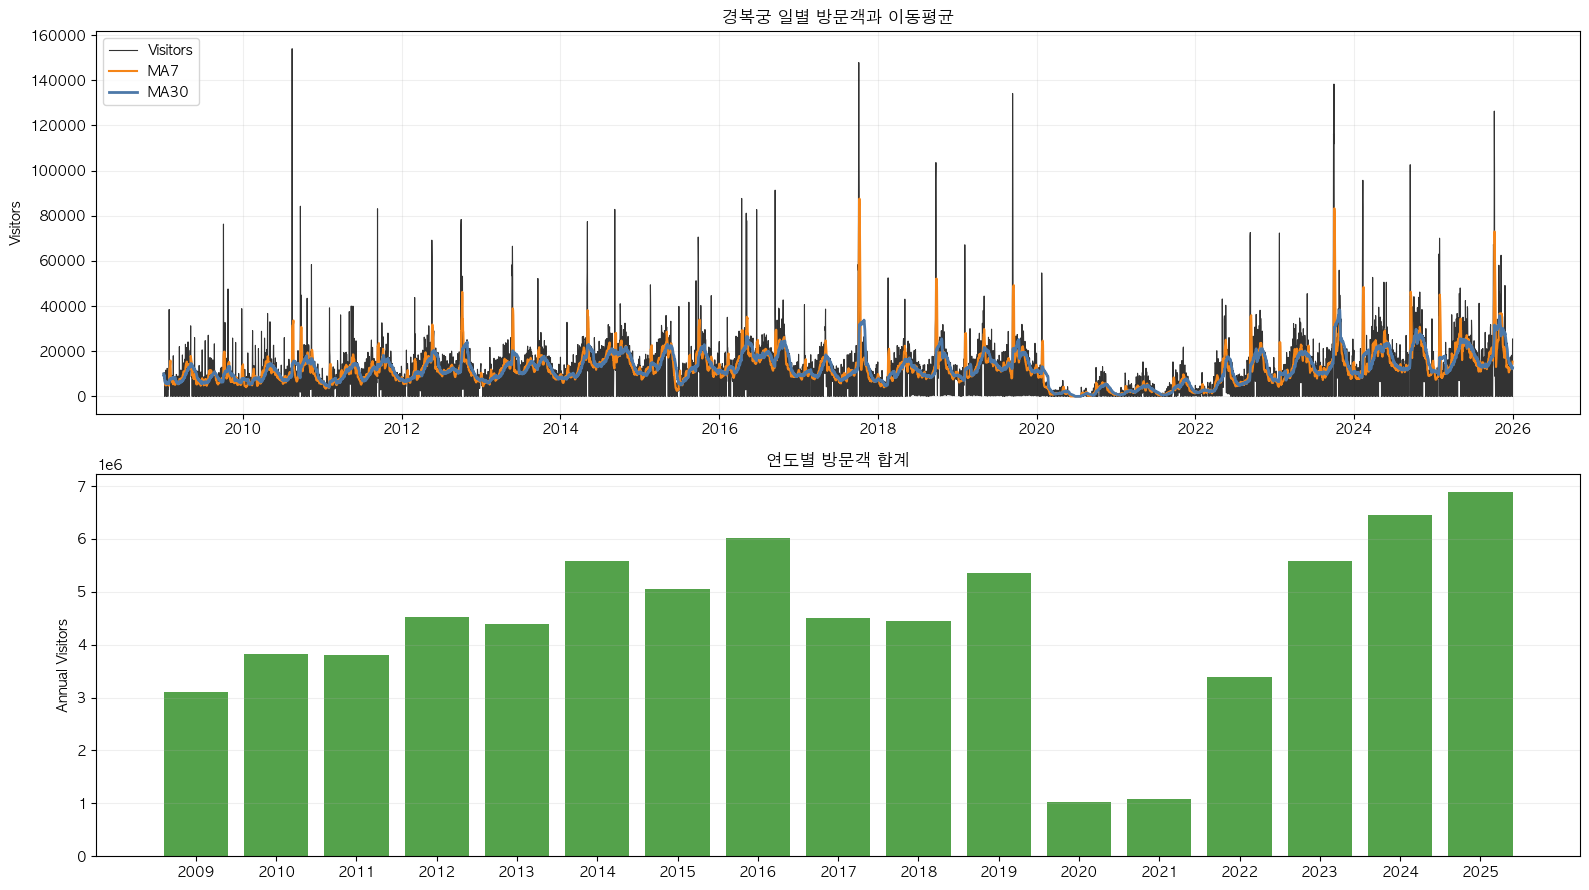

plot rows: 6,209
date range: 2009-01-01 ~ 2025-12-31


In [5]:
# ============================================================
# 4. 방문객 시계열과 추세
# ============================================================
plot_df = master[["date", "visitors"]].copy()
plot_df["date"] = pd.to_datetime(plot_df["date"], errors="coerce")
plot_df["visitors"] = pd.to_numeric(plot_df["visitors"], errors="coerce")
plot_df = plot_df.dropna(subset=["date", "visitors"]).sort_values("date")
plot_df = plot_df.set_index("date")

if plot_df.empty:
    raise ValueError("방문객 시계열 plot용 데이터가 비어 있습니다.")

plot_df["visitors_ma7"] = plot_df["visitors"].rolling(7, min_periods=1).mean()
plot_df["visitors_ma30"] = plot_df["visitors"].rolling(30, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 9), facecolor="white")
for ax in axes:
    ax.set_facecolor("white")

axes[0].plot(plot_df.index, plot_df["visitors"], color="black", linewidth=0.8, alpha=0.8, label="Visitors")
axes[0].plot(plot_df.index, plot_df["visitors_ma7"], color="#F58518", linewidth=1.5, label="MA7")
axes[0].plot(plot_df.index, plot_df["visitors_ma30"], color="#4C78A8", linewidth=2.0, label="MA30")
axes[0].set_title("경복궁 일별 방문객과 이동평균")
axes[0].set_ylabel("Visitors")
axes[0].grid(alpha=0.2)
axes[0].legend(loc="upper left")

annual_visitors = plot_df["visitors"].groupby(plot_df.index.year).sum()
axes[1].bar(annual_visitors.index.astype(str), annual_visitors.values, color="#54A24B")
axes[1].set_title("연도별 방문객 합계")
axes[1].set_ylabel("Annual Visitors")
axes[1].tick_params(axis="x", rotation=0)
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

print(f"plot rows: {len(plot_df):,}")
print(f"date range: {plot_df.index.min().date()} ~ {plot_df.index.max().date()}")


,month,month_mean,month_median
0,1,"7,934.247","7,011.000"
1,2,"9,294.385","8,249.500"
2,3,"9,208.641","8,479.000"
3,4,"14,820.600","15,897.500"
4,5,"16,298.715","15,212.000"
5,6,"10,529.629","10,111.500"
6,7,"9,471.493","9,588.000"
7,8,"11,209.366","11,680.000"
8,9,"15,421.631","12,834.000"
9,10,"20,033.436","19,136.000"


,mean_visitors
dow_name,
월,"12,005.174"
화,"1,168.306"
수,"13,696.521"
목,"12,283.136"
금,"12,216.073"
토,"17,487.583"
일,"15,696.396"


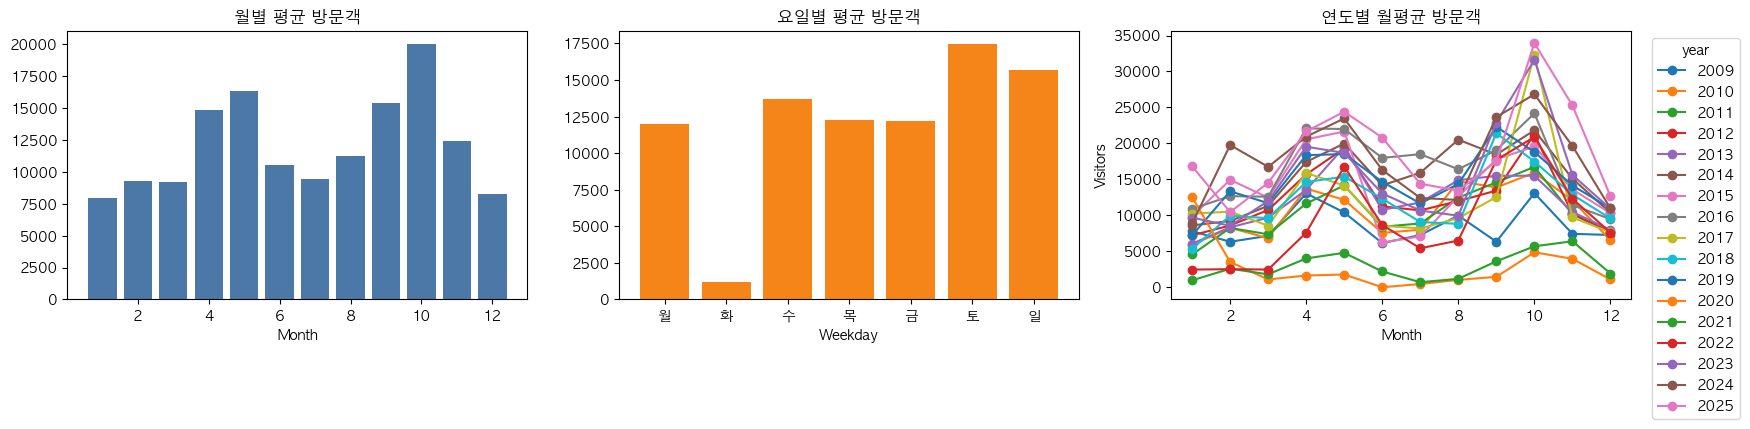

In [6]:
# ============================================================
# 5. 월별 / 요일별 / 연도별 패턴
# ============================================================
calendar_summary = pd.DataFrame({
    "month_mean": master.groupby("month")["visitors"].mean(),
    "month_median": master.groupby("month")["visitors"].median(),
}).reset_index()

dow_order = ["월", "화", "수", "목", "금", "토", "일"]
dow_summary = master.groupby("dow_name")["visitors"].mean().reindex(dow_order)

year_month = master.groupby(["year", "month"], as_index=False)["visitors"].mean()
pivot_year_month = year_month.pivot(index="month", columns="year", values="visitors")

display(calendar_summary)
display(dow_summary.to_frame("mean_visitors"))

fig, axes = plt.subplots(1, 3, figsize=(20, 4))

axes[0].bar(calendar_summary["month"], calendar_summary["month_mean"], color="#4C78A8")
axes[0].set_title("월별 평균 방문객")
axes[0].set_xlabel("Month")

axes[1].bar(dow_summary.index, dow_summary.values, color="#F58518")
axes[1].set_title("요일별 평균 방문객")
axes[1].set_xlabel("Weekday")

pivot_year_month.plot(ax=axes[2], marker="o")
axes[2].set_title("연도별 월평균 방문객")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Visitors")

axes[2].legend(
    title="year",
    bbox_to_anchor=(1.03, 1),
    loc="upper left"
)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

## 5. 코로나 구간 점검

`covid_v1`, `covid_v2`, `covid_v3`는 중첩 더미다. EDA에서는 단계별 수준 차이를 확인하고,
모델링에서는 **하나씩만** 넣는다.

,count,mean,median,std
covid_stage,,,,
stage_1_covid_general,121,"14,680.446","14,751.000","9,643.511"
non_covid_period,4981,"13,575.830","12,144.000","11,674.234"
stage_2_mask_only,287,"11,525.115","8,768.000","11,033.147"
stage_3_distancing,820,"2,796.862","1,446.000","4,172.876"


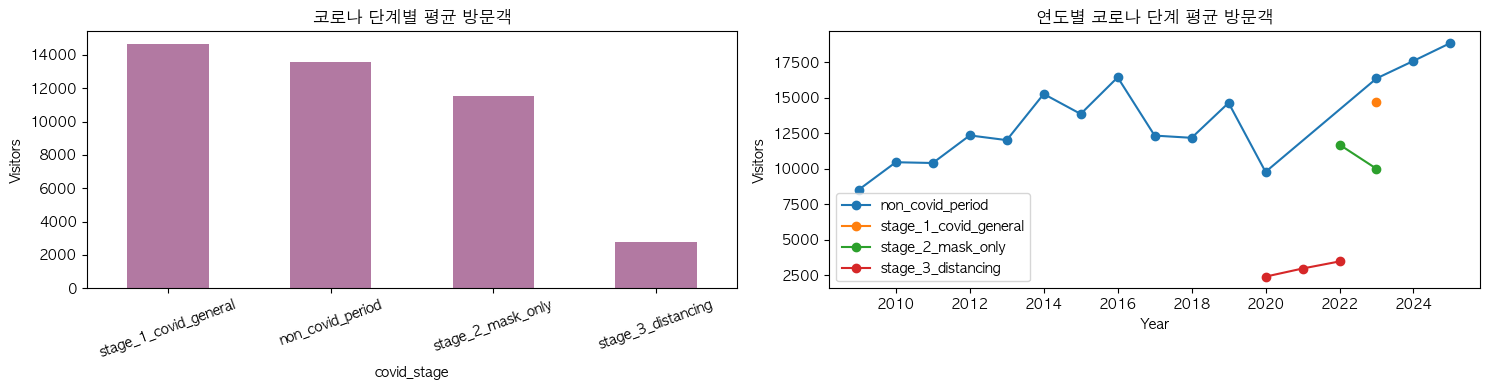

In [7]:
# ============================================================
# 6. 코로나 구간 점검
# ============================================================
covid_stage_summary = master.groupby("covid_stage")["visitors"].agg(["count", "mean", "median", "std"]).sort_values("mean", ascending=False)
display(covid_stage_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
master.groupby("covid_stage")["visitors"].mean().sort_values(ascending=False).plot(kind="bar", ax=axes[0], color="#B279A2")
axes[0].set_title("코로나 단계별 평균 방문객")
axes[0].set_ylabel("Visitors")
axes[0].tick_params(axis="x", rotation=20)

covid_yearly = master.groupby(["year", "covid_stage"], as_index=False)["visitors"].mean()
for stage_name, stage_df in covid_yearly.groupby("covid_stage"):
    axes[1].plot(stage_df["year"], stage_df["visitors"], marker="o", label=stage_name)
axes[1].set_title("연도별 코로나 단계 평균 방문객")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Visitors")
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. 후보 변수 구성

모델 후보는 대략 아래 블록으로 나눈다.
- 날씨/적설
- 미세먼지(관람시간 평균)
- 이벤트
- KTCI 계열
- 코로나 더미
- 운영/캘린더

In [8]:
# ============================================================
# 7. 후보 변수 블록 정의
# ============================================================
WEATHER_COLS = [
    "tavg", "tmin", "tmax", "rain", "rain_yn",
    "snow_fresh_max", "snow_depth_max", "snow_fresh_3h_total", "snow_yn",
    "pleasant", "pleasant_streak", "wind_avg", "humidity_avg",
    "sunshine", "cloud_avg", "solar_total",
]
PM_COLS = [
    "ydst_pm10_all_hours", "ydst_pm10_open_hours", "ydst_pm10_entry_hours",
    "ydst_pm10_count_open_hours", "ydst_pm10_count_entry_hours", "ydst_pm10_high",
]
COVID_COLS = ["covid_v1", "covid_v2", "covid_v3"]
OPERATION_COLS = [
    "is_weekend", "is_regular_closed_tuesday", "close_hour", "last_entry_hour",
    "scheduled_open_hours_nominal", "scheduled_entry_hours_nominal",
]
KTCI_COLS = ["ktci", "ktci_a", "ktci_a2", "ktci_a_roll3", "ktci_a_roll7", "Cd", "Ca", "P", "W", "S"]
EVENT_COLS = [c for c in master.columns if c.endswith("_count") or c == "event_day"]

LEAKAGE_COLS = [
    "paid", "free", "domestic", "english", "japanese", "chinese", "other_foreign", "foreign_total"
]

EDA_FEATURE_COLS = [
    *WEATHER_COLS,
    *PM_COLS,
    *COVID_COLS,
    *OPERATION_COLS,
    *KTCI_COLS,
    *EVENT_COLS,
]
EDA_FEATURE_COLS = [col for col in EDA_FEATURE_COLS if col in master.columns and col not in LEAKAGE_COLS]

print("n feature candidates:", len(EDA_FEATURE_COLS))
display(pd.Series(EDA_FEATURE_COLS, name="feature"))

n feature candidates: 65


0                         tavg
1                         tmin
2                         tmax
3                         rain
4                      rain_yn
                ...           
60               type_전시_count
61               type_체험_count
62    participation_사전예약_count
63    participation_현장참여_count
64                   event_day
Name: feature, Length: 65, dtype: str

In [9]:
# ============================================================
# 8. 결측률 / 동시점 상관 / 기본 분산 점검
# ============================================================
feature_quality = pd.DataFrame({
    "missing_rate": master[EDA_FEATURE_COLS].isna().mean(),
    "nunique": master[EDA_FEATURE_COLS].nunique(dropna=True),
    "std": master[EDA_FEATURE_COLS].std(numeric_only=True),
    "corr_with_visitors": master[["visitors", *EDA_FEATURE_COLS]].corr(numeric_only=True)["visitors"].drop("visitors"),
}).sort_values(["corr_with_visitors"], ascending=False)

display(feature_quality)

,missing_rate,nunique,std,corr_with_visitors
is_weekend,0.000,2,0.452,0.248
ktci_a2,0.000,2778,10.974,0.232
ktci_a,0.000,2567,10.983,0.231
ktci,0.000,2591,11.004,0.230
ktci_a_roll3,0.000,2862,9.212,0.220
...,...,...,...,...
covid_v1,0.000,2,0.398,-0.262
covid_v2,0.000,2,0.383,-0.284
covid_v3,0.000,2,0.339,-0.315
is_regular_closed_tuesday,0.000,2,0.350,-0.387


,visitors,tavg,rain,snow_yn,pleasant_streak,ydst_pm10_open_hours,ydst_pm10_high,event_count,night_event_count,ktci,ktci_a_roll7,covid_v3
visitors,1.000,0.152,-0.081,-0.106,0.132,-0.027,-0.007,0.125,0.143,0.230,0.217,-0.315
tavg,0.152,1.000,0.171,-0.422,-0.009,-0.210,-0.103,0.068,0.068,0.603,0.744,-0.028
rain,-0.081,0.171,1.000,-0.042,-0.056,-0.171,-0.064,0.016,-0.002,-0.449,-0.042,-0.008
snow_yn,-0.106,-0.422,-0.042,1.000,-0.132,0.040,0.009,-0.040,-0.046,-0.360,-0.416,-0.015
pleasant_streak,0.132,-0.009,-0.056,-0.132,1.000,0.114,0.069,0.041,0.081,0.101,0.135,0.033
ydst_pm10_open_hours,-0.027,-0.210,-0.171,0.040,0.114,1.000,0.686,-0.037,-0.020,-0.004,-0.135,-0.008
ydst_pm10_high,-0.007,-0.103,-0.064,0.009,0.069,0.686,1.000,-0.031,-0.016,-0.018,-0.081,0.022
event_count,0.125,0.068,0.016,-0.040,0.041,-0.037,-0.031,1.000,0.639,0.068,0.099,-0.005
night_event_count,0.143,0.068,-0.002,-0.046,0.081,-0.020,-0.016,0.639,1.000,0.079,0.112,-0.018
ktci,0.230,0.603,-0.449,-0.360,0.101,-0.004,-0.018,0.068,0.079,1.000,0.737,-0.015


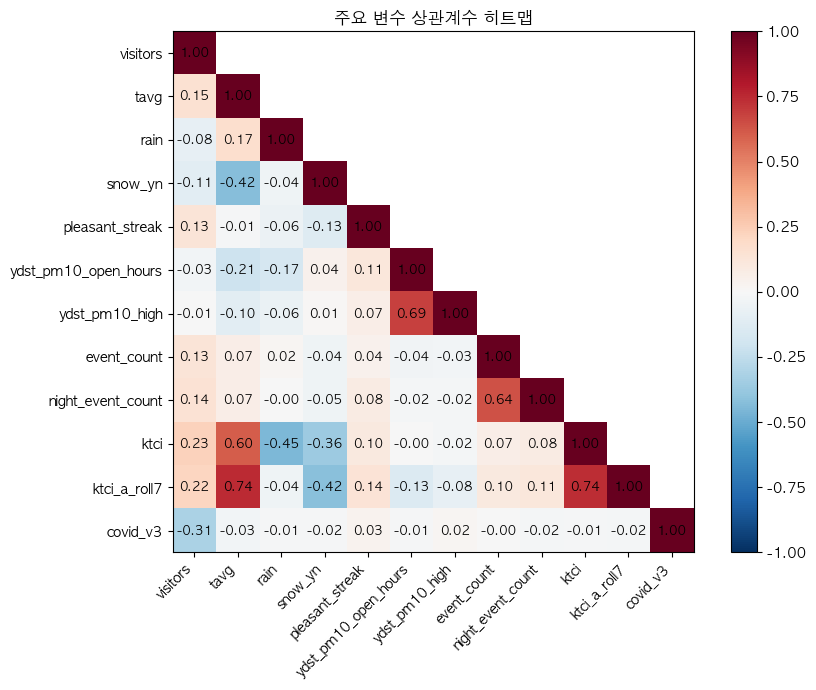

In [18]:
# ============================================================
# 9. 주요 후보 변수 상관관계
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

focus_cols = [
    "visitors", "tavg", "rain", "snow_yn", "pleasant_streak",
    "ydst_pm10_open_hours", "ydst_pm10_high", "event_count",
    "night_event_count", "ktci", "ktci_a_roll7", "covid_v3",
]

focus_cols = [col for col in focus_cols if col in master.columns]

focus_corr = master[focus_cols].corr(numeric_only=True)
display(focus_corr)

# 상삼각 마스킹: k=1이면 대각선 위쪽만 가림
mask = np.triu(np.ones_like(focus_corr, dtype=bool), k=1)

# 마스킹된 배열 생성
corr_masked = np.ma.array(focus_corr, mask=mask)

fig, ax = plt.subplots(figsize=(10, 7))

plt.cm.RdBu_r.set_bad(color="white")
im = ax.imshow(
    corr_masked,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(focus_cols)))
ax.set_xticklabels(focus_cols, rotation=45, ha="right")

ax.set_yticks(range(len(focus_cols)))
ax.set_yticklabels(focus_cols)

ax.set_title("주요 변수 상관계수 히트맵")

# 각 셀 위에 숫자 표시: 하삼각 + 대각선만
for i in range(len(focus_cols)):
    for j in range(len(focus_cols)):
        if i >= j:
            value = focus_corr.iloc[i, j]
            ax.text(
                j, i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=9,
                color="black"
            )

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# 10. 시차 상관관계 점검
# ============================================================
def lag_corr_table(frame, target_col, feature_cols, lags=(0, 1, 3, 7, 14, 30)):
    rows = []
    for feature in feature_cols:
        for lag in lags:
            shifted = frame[feature].shift(lag)
            corr = frame[target_col].corr(shifted)
            rows.append({"feature": feature, "lag": lag, "corr": corr})
    result = pd.DataFrame(rows)
    best = result.loc[result.groupby("feature")["corr"].apply(lambda s: s.abs().idxmax())].copy()
    best["abs_corr"] = best["corr"].abs()
    return result, best.sort_values("abs_corr", ascending=False)

lag_features = [
    col for col in [
        "tavg", "rain", "snow_yn", "pleasant_streak", "ydst_pm10_open_hours",
        "event_count", "night_event_count", "ktci", "ktci_a_roll7",
    ] if col in master.columns
]
lag_all, lag_best = lag_corr_table(master, "visitors", lag_features)
display(lag_best)

,feature,lag,corr,abs_corr
42,ktci,0,0.230,0.230
48,ktci_a_roll7,0,0.217,0.217
0,tavg,0,0.152,0.152
36,night_event_count,0,0.143,0.143
18,pleasant_streak,0,0.132,0.132
30,event_count,0,0.125,0.125
12,snow_yn,0,-0.106,0.106
6,rain,0,-0.081,0.081
26,ydst_pm10_open_hours,3,-0.045,0.045


,count,mean_visitors,mean_uplift,median_uplift
event_day,,,,
0,5565,"11,762.624",-83.180,-409.384
1,644,"14,813.160",718.781,"-1,696.019"


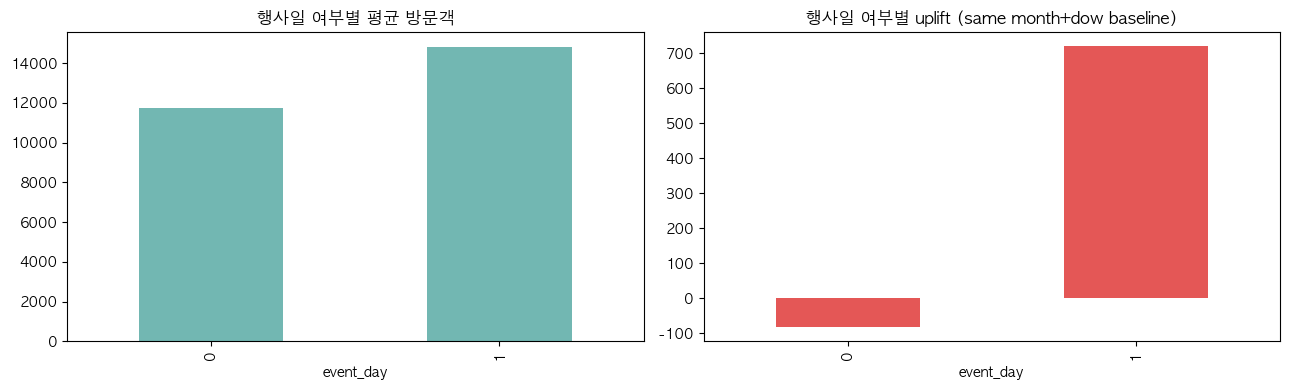

In [20]:
# ============================================================
# 11. 이벤트일 uplift 분석
# ============================================================
event_eval = master[["date", "year", "month", "dow_name", "visitors", "event_day", "event_count"]].copy()
event_eval["event_day"] = event_eval["event_day"].fillna(0).astype(int)

baseline = (
    event_eval.groupby(["month", "dow_name"], as_index=False)["visitors"]
    .mean()
    .rename(columns={"visitors": "baseline_visitors_same_month_dow"})
)
event_eval = event_eval.merge(baseline, on=["month", "dow_name"], how="left")
event_eval["uplift_vs_month_dow"] = event_eval["visitors"] - event_eval["baseline_visitors_same_month_dow"]

event_summary = event_eval.groupby("event_day").agg(
    count=("visitors", "count"),
    mean_visitors=("visitors", "mean"),
    mean_uplift=("uplift_vs_month_dow", "mean"),
    median_uplift=("uplift_vs_month_dow", "median"),
)
display(event_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
event_summary["mean_visitors"].plot(kind="bar", ax=axes[0], color="#72B7B2")
axes[0].set_title("행사일 여부별 평균 방문객")
axes[0].set_xlabel("event_day")

event_summary["mean_uplift"].plot(kind="bar", ax=axes[1], color="#E45756")
axes[1].set_title("행사일 여부별 uplift (same month+dow baseline)")
axes[1].set_xlabel("event_day")
plt.tight_layout()
plt.show()

## 7. EDA 정리 및 모델링 메모

아래 표는 EDA 기준으로 변수 블록을 정리한 것이다.
- 모델링에서는 leakage 변수 제외
- 코로나 더미는 `v1/v2/v3` 중 하나만 사용
- PM은 우선 `ydst_pm10_open_hours` 사용
- 적설은 `snow_yn` 또는 `snow_depth_max`로 단순화 가능

In [21]:
# ============================================================
# 12. 모델링 메모 정리
# ============================================================
recommendation_rows = [
    {
        "block": "calendar/operation",
        "recommended": "is_weekend, is_regular_closed_tuesday, close_hour",
        "note": "주간 패턴과 운영시간 차이를 먼저 통제",
    },
    {
        "block": "covid",
        "recommended": "covid_v1 or covid_v2 or covid_v3",
        "note": "세 변수는 중첩 관계라 하나씩만 비교",
    },
    {
        "block": "weather",
        "recommended": "tavg/tmin/tmax, rain, snow_yn, pleasant_streak",
        "note": "봄·가을 성수기와 강수/적설 영향을 분리해서 확인",
    },
    {
        "block": "air quality",
        "recommended": "ydst_pm10_open_hours, ydst_pm10_high",
        "note": "하루 전체 평균보다 관람시간 평균이 해석상 더 적절",
    },
    {
        "block": "event",
        "recommended": "event_count, night_event_count, reservation_event_count",
        "note": "방문객 급증일 설명력 점검용",
    },
    {
        "block": "thermal index",
        "recommended": "ktci_a_roll7 or decomposition(Cd,Ca,P,W,S)",
        "note": "동일 모델에 중복 투입보다는 대안 스펙으로 비교",
    },
]
recommendation_df = pd.DataFrame(recommendation_rows)
display(recommendation_df)

summary_stats = {
    "rows": len(master),
    "start_date": master["date"].min().strftime("%Y-%m-%d"),
    "end_date": master["date"].max().strftime("%Y-%m-%d"),
    "zero_visitors_days": int((master["visitors"] == 0).sum()),
    "missing_asos_tavg": int(master["tavg"].isna().sum()),
    "missing_pm_open": int(master["ydst_pm10_open_hours"].isna().sum()),
    "event_days": int(master["event_day"].sum()),
}
display(pd.Series(summary_stats, name="eda_summary"))

,block,recommended,note
0,calendar/operation,"is_weekend, is_regular_closed_tuesday, close_hour",주간 패턴과 운영시간 차이를 먼저 통제
1,covid,covid_v1 or covid_v2 or covid_v3,세 변수는 중첩 관계라 하나씩만 비교
2,weather,"tavg/tmin/tmax, rain, snow_yn, pleasant_streak",봄·가을 성수기와 강수/적설 영향을 분리해서 확인
3,air quality,"ydst_pm10_open_hours, ydst_pm10_high",하루 전체 평균보다 관람시간 평균이 해석상 더 적절
4,event,"event_count, night_event_count, reservation_ev...",방문객 급증일 설명력 점검용
5,thermal index,"ktci_a_roll7 or decomposition(Cd,Ca,P,W,S)",동일 모델에 중복 투입보다는 대안 스펙으로 비교


rows                        6209
start_date            2009-01-01
end_date              2025-12-31
zero_visitors_days           705
missing_asos_tavg              0
missing_pm_open              283
event_days                   644
Name: eda_summary, dtype: object

# 사용 메모

- 이 노트북은 `data/preprocessed/`의 전처리 파일을 그대로 읽는다.
- 병합 결과는 `data/preprocessed/eda_gbg_master.csv`로 저장된다.
- 다음 단계인 SARIMAX 노트북에서는 이 EDA 결과를 보고 feature block별로 스펙을 나눠 비교하면 된다.